### Import modules

In [1]:
# Standard imports
import pandas as pd
import sys 
import os
import seaborn as sns
import os
import shutil
import matplotlib
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
#sns.set(font='Adobe Devanagari')
sns.set_context("paper", font_scale=0.8, rc={"lines.linewidth": 0.5, "grid.linewidth": 0.3})


matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
# Not italized latex
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams["font.weight"] = "light"

%config InlineBackend.figure_format='svg'

In [2]:
import plotly.graph_objects as go
import plotly.express as px
import json
import numpy as np
# Get filling scheme (json file)
path_filling_scheme = "/afs/cern.ch/work/c/cdroin/private/example_DA_study/master_study/master_jobs/filling_scheme/25ns_2228b_2216_1686_2112_hybrid_8b4e_2x56b_25ns_3x48b_12inj.json"
# path_filling_scheme = "/afs/cern.ch/work/c/cdroin/private/comparison_pymask_xmask/filling_scheme/8b4e_1972b_1960_1178_1886_224bpi_12inj_800ns_bs200ns.json"
with open(path_filling_scheme) as fid:
    filling_scheme = json.load(fid)

array_b1 = np.array(filling_scheme["beam1"])
array_b2 = np.array(filling_scheme["beam2"])

non_zero_indices_b1 = np.nonzero(array_b1)[0]
non_zero_indices_b2 = np.nonzero(array_b2)[0]

array_b1_colored = np.array([[30,144,255,1] if x!=0 else [255,255,255,0] for x in array_b1], dtype=np.uint8)
array_b2_colored = np.array([[238,75,43,1] if x!=0 else [255,255,255,0] for x in array_b2], dtype=np.uint8)

mat = np.stack((array_b1_colored, array_b2_colored), dtype=np.uint8)





In [11]:
fig = go.Figure()
end = 500
fig.add_trace(
    go.Scattergl(
        x=non_zero_indices_b1[:end],
        y=array_b1[non_zero_indices_b1][:end],
        mode="markers",
        marker=dict(color="blue", size=10),
        #name="Beam 1",
        marker_symbol='line-ns',
    )
)
fig.add_trace(
    go.Scattergl(
        x=non_zero_indices_b2[:end],
        y=array_b2[non_zero_indices_b2][:end]*2,
        mode="markers",
        marker=dict(color="red", size=10),
        #name="Beam 2",
        marker_symbol='line-ns',
    )
)
fig.update_yaxes(range=[0.9, 2.1])
#fig.update_xaxes(range=[0, 900])
fig.update_layout(
    xaxis=dict(
        title="Bucket number",
        #tickmode="array",
        #tickvals=np.arange(len(array_b1))[:100],
        #ticktext=np.arange(len(array_b1))[:100] + 1,
    ),
    yaxis=dict(title="Beam"),
    #title="Filling scheme",
    width=2000,
    height=420,
    
)
fig.update_layout(
    yaxis = dict(
        tickmode = 'linear',
        tick0 = 1,
        dtick = 1
    )
)
fig.update_layout(showlegend=False, template="none")
# use whitegrid theme

#fig.write_image("filling.svg")
fig.show()


In [4]:
import fillingpatterns as fp

patt = fp.FillingPattern.from_json(path_filling_scheme)
patt.compute_beam_beam_schedule(n_lr_per_side=26)

sched_b1 = patt.b1.bb_schedule
sched_b2 = patt.b2.bb_schedule

Computing collision schedules...
Done Beam 1
Done Beam 2


In [5]:
sched_b1 

,HO partner in ALICE,# of LR in ALICE,BB partners in ALICE,Positions in ALICE,HO partner in ATLAS/CMS,# of LR in ATLAS/CMS,BB partners in ATLAS/CMS,Positions in ATLAS/CMS,HO partner in LHCB,# of LR in LHCB,BB partners in LHCB,Positions in LHCB,collides in ATLAS/CMS,collides in ALICE,collides in LHCB
0,891.0,36,"[865.0, 866.0, 867.0, 868.0, 869.0, 874.0, 875...","[-26.0, -25.0, -24.0, -23.0, -22.0, -17.0, -16...",NaN,12,"[12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19....","[12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19....",NaN,34,"[2644.0, 2645.0, 2650.0, 2651.0, 2652.0, 2653....","[-26.0, -25.0, -20.0, -19.0, -18.0, -17.0, -16...",False,True,False
1,892.0,35,"[866.0, 867.0, 868.0, 869.0, 874.0, 875.0, 876...","[-26.0, -25.0, -24.0, -23.0, -18.0, -17.0, -16...",NaN,12,"[12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19....","[11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18....",NaN,33,"[2645.0, 2650.0, 2651.0, 2652.0, 2653.0, 2654....","[-26.0, -21.0, -20.0, -19.0, -18.0, -17.0, -16...",False,True,False
2,893.0,34,"[867.0, 868.0, 869.0, 874.0, 875.0, 876.0, 877...","[-26.0, -25.0, -24.0, -19.0, -18.0, -17.0, -16...",NaN,12,"[12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19....","[10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17....",NaN,33,"[2650.0, 2651.0, 2652.0, 2653.0, 2654.0, 2655....","[-22.0, -21.0, -20.0, -19.0, -18.0, -17.0, -16...",False,True,False
3,NaN,34,"[868.0, 869.0, 874.0, 875.0, 876.0, 877.0, 878...","[-26.0, -25.0, -20.0, -19.0, -18.0, -17.0, -16...",NaN,12,"[12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19....","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...",NaN,34,"[2650.0, 2651.0, 2652.0, 2653.0, 2654.0, 2655....","[-23.0, -22.0, -21.0, -20.0, -19.0, -18.0, -17...",False,False,False
4,NaN,33,"[869.0, 874.0, 875.0, 876.0, 877.0, 878.0, 879...","[-26.0, -21.0, -20.0, -19.0, -18.0, -17.0, -16...",NaN,12,"[12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19....","[8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0,...",2674.0,34,"[2650.0, 2651.0, 2652.0, 2653.0, 2654.0, 2655....","[-24.0, -23.0, -22.0, -21.0, -20.0, -19.0, -18...",False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3427,NaN,22,"[728.0, 729.0, 730.0, 731.0, 732.0, 733.0, 734...","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",3427.0,30,"[3401.0, 3402.0, 3403.0, 3404.0, 3405.0, 3406....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",2533.0,30,"[2507.0, 2508.0, 2509.0, 2510.0, 2511.0, 2512....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",True,False,True
3428,NaN,21,"[729.0, 730.0, 731.0, 732.0, 733.0, 734.0, 735...","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",3428.0,29,"[3402.0, 3403.0, 3404.0, 3405.0, 3406.0, 3407....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",2534.0,29,"[2508.0, 2509.0, 2510.0, 2511.0, 2512.0, 2513....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",True,False,True
3429,NaN,20,"[730.0, 731.0, 732.0, 733.0, 734.0, 735.0, 736...","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",3429.0,28,"[3403.0, 3404.0, 3405.0, 3406.0, 3407.0, 3408....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",2535.0,28,"[2509.0, 2510.0, 2511.0, 2512.0, 2513.0, 2514....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",True,False,True
3430,NaN,19,"[731.0, 732.0, 733.0, 734.0, 735.0, 736.0, 737...","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",3430.0,27,"[3404.0, 3405.0, 3406.0, 3407.0, 3408.0, 3409....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",2536.0,27,"[2510.0, 2511.0, 2512.0, 2513.0, 2514.0, 2515....","[-26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20...",True,False,True


In [20]:
for ib, beam in zip([1], [patt.b1]):

    bbs = beam.bb_schedule

    fig1 = plt.figure(100 + ib, figsize=(6.4*1.5, 1.6*4.8))
    ax1 = fig1.add_subplot(4, 1, 1)
    ax2 = fig1.add_subplot(4, 1, 2, sharex=ax1)
    ax3 = fig1.add_subplot(4, 1, 3, sharex=ax1)
    ax4 = fig1.add_subplot(4, 1, 4, sharex=ax1)

    ax1.plot(bbs['collides in ATLAS/CMS'], '.', color='b', label='ATLAS/CMS')
    ax1.plot(0.05 +bbs['collides in LHCB'], '.', color='r', label='LHCB')
    ax1.plot(-0.05 + bbs['collides in ALICE'],'.', color='g', label='ALICE')
    ax1.legend(ncol=6, loc='center right', fontsize='medium')

    ax1.plot(bbs['collides in ATLAS/CMS'], '.', color='b')
    ax1.plot(0.05 +bbs['collides in LHCB'], '.', color='r')
    ax1.plot(-0.05 + bbs['collides in ALICE'],'.', color='g')

    ax2.plot(bbs['# of LR in ATLAS/CMS'], '.', color='b')
    ax3.plot(bbs['# of LR in LHCB'], '.', color='r')
    ax4.plot(bbs['# of LR in ALICE'], '.', color='g')

    ax1.set_ylabel('Head-on')
    ax2.set_ylabel('N. LR in ATLAS/CMS')
    ax3.set_ylabel('N. LR in LHCB')
    ax4.set_ylabel('N. LR in ALICE')

    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['No', 'Yes'])
    ax4.set_xlim(0, 3500)
    ax4.set_xlabel('25 ns slot')

    for aa in [ax1, ax2, ax3]:
        aa.tick_params(labelbottom=False)

    for aa in [ax1, ax2, ax3, ax4]:
        aa.grid(True, linestyle=':')

    for aa in [ax2, ax3, ax4]:
        aa.set_ylim(0,50)

    fig1.subplots_adjust(left=.06, right=.96, top=.92)
    #fig1.suptitle(patt.scheme_name + ' - ' + beam.beam_name)

    #fig1.savefig(fname.split('.csv')[0] + f"_{beam.beam_name.replace(' ', '')}_bb_summary.png", dpi=200)
ax1.grid(True, linestyle='-')
ax2.grid(True, linestyle='-')   
ax3.grid(True, linestyle='-')
ax4.grid(True, linestyle='-')
#plt.show()
plt.savefig("schedule_filling_scheme_8b4e.pdf")

In [43]:
from plotly.subplots import make_subplots
fig = make_subplots(rows=4, cols=1, shared_xaxes=True)
scat_1 = go.Scattergl(
        x=non_zero_indices_b1,
        y=array_b1[non_zero_indices_b1],
        xaxis="x",
        yaxis="y",
        mode="markers",
        marker=dict(color="blue", size=10),
        #name="Beam 1",
        marker_symbol='line-ns',
        showlegend=False
    )
fig.append_trace(
    scat_1,
    row=1,
    col=1,
)

series_collide_atlas_cms = bbs[bbs['collides in ATLAS/CMS']]['# of LR in ATLAS/CMS']
series_not_collide_atlas_cms = bbs[~bbs['collides in ATLAS/CMS']]['# of LR in ATLAS/CMS']
series_collide_lhcb = bbs[bbs['collides in LHCB']]['# of LR in LHCB']
series_not_collide_lhcb = bbs[~bbs['collides in LHCB']]['# of LR in LHCB']
series_collide_alice = bbs[bbs['collides in ALICE']]['# of LR in ALICE']
series_not_collide_alice = bbs[~bbs['collides in ALICE']]['# of LR in ALICE']



fig.append_trace(
    go.Scattergl(x = series_collide_atlas_cms.index, y = series_collide_atlas_cms, xaxis="x", yaxis="y2", mode='markers', marker=dict(color="orange", size=5, ), showlegend=False),
    row=2,
    col=1,
)
fig.append_trace(
    go.Scattergl(x = series_not_collide_atlas_cms.index, y = series_not_collide_atlas_cms, xaxis="x", yaxis="y2", mode='markers', marker=dict(color="teal", size=5, ), showlegend=False),
    row=2,
    col=1,
)

fig.append_trace(
    go.Scattergl(x = series_collide_lhcb.index, y = series_collide_lhcb, xaxis="x", yaxis="y3", mode='markers', marker=dict(color="orange", size=5, ), showlegend=False),
    row=3,
    col=1,
)
fig.append_trace(
    go.Scattergl(x = series_not_collide_lhcb.index, y = series_not_collide_lhcb, xaxis="x", yaxis="y3", mode='markers', marker=dict(color="teal", size=5, ), showlegend=False),
    row=3,
    col=1,
)

fig.append_trace(
    go.Scattergl(x = series_collide_alice.index, y = series_collide_alice, xaxis="x", yaxis="y4", mode='markers', marker=dict(color="teal", size=5, ), showlegend=False),
    row=4,
    col=1,
)

fig.append_trace(
    go.Scattergl(x = series_not_collide_alice.index, y = series_not_collide_alice, xaxis="x", yaxis="y4", mode='markers', marker=dict(color="orange", size=5), showlegend=False),
    row=4,
    col=1,
)

# Traces for legend
fig.append_trace(
    go.Scattergl(x = series_collide_atlas_cms.index[:1], y = series_collide_atlas_cms.values[:1], xaxis="x", yaxis="y2", mode='markers', marker=dict(color="orange", size=5), name="Colliding in IP"),
    row=2,
    col=1,
)
fig.append_trace(
    go.Scattergl(x = series_not_collide_atlas_cms.index[:1], y = series_not_collide_atlas_cms.values[:1], xaxis="x", yaxis="y2", mode='markers', marker=dict(color="teal", size=5), name="Not colliding in IP"),
    row=2,
    col=1,
)

# Update yaxis properties
fig.update_xaxes(range=[0, non_zero_indices_b1[-1] + 1])
fig.update_yaxes(title_text=r"Filling scheme$", range=[0.7, 2.3], row=1, col=1)
fig.update_yaxes(title_text=r"#LR in Atlas/CMS", range=[0, 52], row=2, col=1)
fig.update_yaxes(title_text=r"#LR in LHCb", range=[0, 52], row=3, col=1)
fig.update_yaxes(title_text=r"#LR in ALice", range=[0, 52],row=4, col=1)
fig.update_xaxes(title_text=r"25ns slot", row=4, col=1)
fig.update_yaxes(fixedrange=True)

# Update layout
fig.update_layout(
    showlegend=True,
    xaxis_showgrid=True,
    yaxis_showgrid=True,
    dragmode="pan",
    uirevision="Don't change",
    margin=dict(l=10, r=10, b=10, t=10, pad=10),
    template="plotly_dark", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
    legend_x=1, legend_y=0.5,
)
    
fig.show()

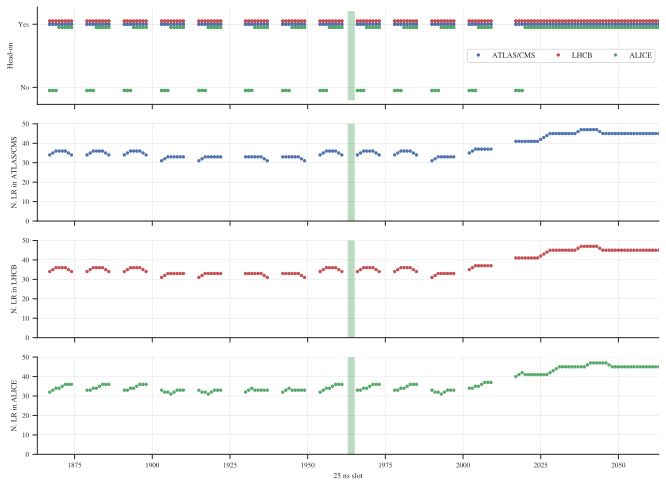

In [7]:
from matplotlib.patches import Rectangle

# Zoom on selected bunch 
bunch_to_zoom = 1963
for ib, beam in zip([1], [patt.b1]):

    bbs = beam.bb_schedule.loc[bunch_to_zoom-100:bunch_to_zoom+100]

    fig1 = plt.figure(100 + ib, figsize=(6.4*1.5, 1.6*4.8))
    ax1 = fig1.add_subplot(4, 1, 1)
    ax2 = fig1.add_subplot(4, 1, 2, sharex=ax1)
    ax3 = fig1.add_subplot(4, 1, 3, sharex=ax1)
    ax4 = fig1.add_subplot(4, 1, 4, sharex=ax1)

    ax1.plot(bbs['collides in ATLAS/CMS'], '.', color='b', label='ATLAS/CMS')
    ax1.plot(0.05 +bbs['collides in LHCB'], '.', color='r', label='LHCB')
    ax1.plot(-0.05 + bbs['collides in ALICE'],'.', color='g', label='ALICE')
    ax1.legend(ncol=6, loc='center right', fontsize='medium')

    ax1.plot(bbs['collides in ATLAS/CMS'], '.', color='b')
    ax1.plot(0.05 +bbs['collides in LHCB'], '.', color='r')
    ax1.plot(-0.05 + bbs['collides in ALICE'],'.', color='g')

    ax2.plot(bbs['# of LR in ATLAS/CMS'], '.', color='b')
    ax3.plot(bbs['# of LR in LHCB'], '.', color='r')
    ax4.plot(bbs['# of LR in ALICE'], '.', color='g')

    # Add retangles
    ax1.add_patch(Rectangle((bunch_to_zoom, -0.2), 2, 1.4, fill=True, alpha=0.4, color='g'))
    ax2.add_patch(Rectangle((bunch_to_zoom, 0), 2, 70, fill=True, alpha=0.4, color='g'))
    ax3.add_patch(Rectangle((bunch_to_zoom, 0), 2, 70, fill=True, alpha=0.4, color='g'))
    ax4.add_patch(Rectangle((bunch_to_zoom, 0), 2, 70, fill=True, alpha=0.4, color='g'))


    ax1.set_ylabel('Head-on')
    ax2.set_ylabel('N. LR in ATLAS/CMS')
    ax3.set_ylabel('N. LR in LHCB')
    ax4.set_ylabel('N. LR in ALICE')

    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['No', 'Yes'])
    ax4.set_xlim(bunch_to_zoom-100, bunch_to_zoom+100)
    ax4.set_xlabel('25 ns slot')

    for aa in [ax1, ax2, ax3]:
        aa.tick_params(labelbottom=False)

    for aa in [ax1, ax2, ax3, ax4]:
        aa.grid(True, linestyle=':')

    for aa in [ax2, ax3, ax4]:
        aa.set_ylim(0,50)

    fig1.subplots_adjust(left=.06, right=.96, top=.92)
    #fig1.suptitle(patt.scheme_name + ' - ' + beam.beam_name)

    #fig1.savefig(fname.split('.csv')[0] + f"_{beam.beam_name.replace(' ', '')}_bb_summary.png", dpi=200)
ax1.grid(True, linestyle='-')
ax2.grid(True, linestyle='-')   
ax3.grid(True, linestyle='-')
ax4.grid(True, linestyle='-')
#plt.show()
plt.savefig("8b4e_zoomed.pdf")

In [31]:
bbs['collides in LHCB']

0       False
1       False
2       False
3       False
4        True
        ...  
3427     True
3428     True
3429     True
3430     True
3431     True
Name: collides in LHCB, Length: 2228, dtype: bool

In [9]:
# Find bunch that do not collider in LHCb
bunches_not_colliding = beam.bb_schedule.loc[beam.bb_schedule['collides in LHCB'] == False].index

In [10]:
# Find bunch with identical BB schedule